# Bortezomib resistance → AnnData

Bortezomib-resistant clones ([`cpg0024`](https://broadinstitute.github.io/cellpainting-gallery/)). Distributed as parquet with only the unnormalized aggregated profiles, so this is the rawest input of any dataset here.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*.parquet" \
  s3://cellpainting-gallery/cpg0024-bortezomib/source_4/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0024-bortezomib/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.parquet")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

2 batches, using 2021_08_23_Batch12


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

AnnData object with n_obs × n_vars = 768 × 4762
    obs: 'Source', 'Plate', 'Well', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "batch"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_Area,cells,areashape,NaN,NaN,0
Cells_AreaShape_BoundingBoxArea,cells,areashape,NaN,NaN,0
Cells_AreaShape_BoundingBoxMaximum_X,cells,areashape,NaN,NaN,0
Cells_AreaShape_BoundingBoxMaximum_Y,cells,areashape,NaN,NaN,0
Cells_AreaShape_BoundingBoxMinimum_X,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_Variance_RNA_3_03_256,nuclei,texture,rna,NaN,1
Nuclei_Texture_Variance_RNA_5_00_256,nuclei,texture,rna,NaN,1
Nuclei_Texture_Variance_RNA_5_01_256,nuclei,texture,rna,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Plate"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

768 wells x 4,695 features
non-finite: 0 | max|x|: 412360.0

Plate:
Plate
BR00126734    384
BR00126735    384


In [6]:
adata.write_h5ad(PROFILES.parent / "bortezomib.h5ad")

## UMAP

These are aggregated but not normalized, so features are scaled before PCA.

In [7]:
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate"]))

,observed,baseline,ratio
covariate,,,
Plate,0.834,0.5,1.667


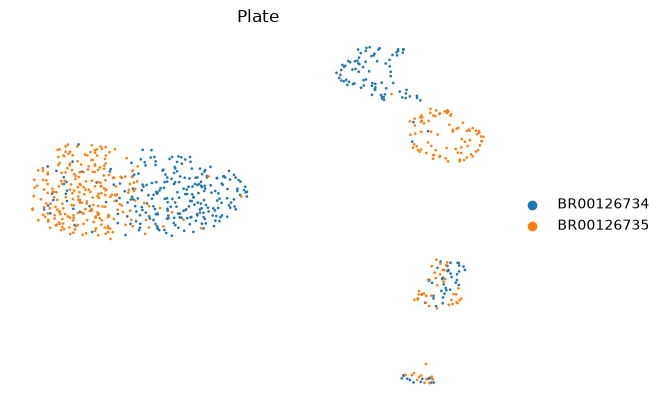

In [9]:
sc.pl.umap(adata, color=present(["Plate", "Count_Cells", "Site_Count"])[:3], ncols=3, frameon=False, size=15)